In [1]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,
    "context_size": 1024,
    "num_layers": 12,
    "num_heads": 12,
    "hidden_size": 768,
    "drop_rate": 0.1,
    "qkv_bias": False,
}

model.to(cuda) 只移动注册的 parameters 和 buffers。输入张量 idx 必须手动移到相同设备

In [2]:
import torch
from torch import nn

class DummyTransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
    
    def forward(self, x):
        # For demonstration, we will just return the input as output
        return x

class DummyLayerNorm(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
    
    def forward(self, x):
        # For demonstration, we will just return the input as output
        return x
    
class DummyGPT(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.pos_emb = nn.Embedding(cfg["context_size"], cfg["hidden_size"])
        self.token_emb = nn.Embedding(cfg["vocab_size"], cfg["hidden_size"])
        self.dropout = nn.Dropout(cfg["drop_rate"])
        self.blocks = nn.Sequential(
            *[DummyTransformerBlock(cfg) for _ in range(cfg["num_layers"])]
        )
        self.final_norm = DummyLayerNorm(cfg)
        self.out_head = nn.Linear(cfg["hidden_size"], cfg["vocab_size"], bias=False)
    
    def forward(self, idx):
        b,t = idx.size()
        pos_embeds = self.pos_emb(torch.arange(t, device=idx.device))  # (t, hidden_size)
        token_embeds = self.token_emb(idx)  # (b, t, hidden_size)
        x = self.dropout(pos_embeds + token_embeds)  # (b, t, hidden_size)
        x = self.blocks(x)  # (b, t, hidden_size)
        x = self.final_norm(x)  # (b, t, hidden_size)
        return self.out_head(x)  # (b, t, vocab_size)

In [3]:
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")
batch = []
t1 = " That is a test"
t2 = " This is another test"
batch.append(torch.tensor(tokenizer.encode(t1)))
batch.append(torch.tensor(tokenizer.encode(t2)))
batch = torch.stack(batch, dim=0)  # (b, t)
print(batch)

tensor([[1320,  318,  257, 1332],
        [ 770,  318, 1194, 1332]])


In [4]:
model = DummyGPT(GPT_CONFIG_124M)
logits = model(batch)
print(logits.shape)  # (b, t, vocab_size)

torch.Size([2, 4, 50257])


In [5]:
batch_example = torch.randn(2, 5)  # (b, t)
layer = nn.Linear(5, 7)

output = layer(batch_example)
print(output) 

tensor([[ 0.7261,  0.3985, -0.6834, -0.1801,  0.7857, -0.1333, -0.3761],
        [ 0.4931,  0.5915, -0.1605, -0.0159,  0.8500,  0.9150, -0.4981]],
       grad_fn=<AddmmBackward0>)


In [6]:
print(output.mean(dim=-1, keepdim=True))  # (b, t, 1)
print(output.var(dim=-1, keepdim=True, unbiased=False))  # (b, t, 1)

tensor([[0.0768],
        [0.3107]], grad_fn=<MeanBackward1>)
tensor([[0.2744],
        [0.2501]], grad_fn=<VarBackward0>)


In [7]:
mean_ = output.mean(dim=-1, keepdim=True)  # (b, t, 1)
var_ = output.var(dim=-1, keepdim=True, unbiased=False)  
normalized_output = (output - mean_) / torch.sqrt(var_ + 1e-5)  # (b, t, 7)
print(normalized_output.mean(dim=-1))  # Should be close to 0
print(normalized_output.var(dim=-1, unbiased=False))  # Should be close to

tensor([-4.2575e-09,  5.1090e-08], grad_fn=<MeanBackward1>)
tensor([1.0000, 1.0000], grad_fn=<VarBackward0>)


在打印时禁用科学计数法

unbiased=False,计算时除以n，这是有偏估计。
pytorch默认无偏，这里为了符合TensorFlow的默认做法

In [8]:
torch.set_printoptions(sci_mode=False)
print(normalized_output.mean(dim=-1))  # Should be close to 0
print(normalized_output.var(dim=-1, unbiased=False))  # Should be close to

tensor([    -0.0000,      0.0000], grad_fn=<MeanBackward1>)
tensor([1.0000, 1.0000], grad_fn=<VarBackward0>)


In [9]:
class LayerNorm(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.shift = nn.Parameter(torch.zeros(cfg["hidden_size"]))
        self.scale = nn.Parameter(torch.ones(cfg["hidden_size"]))
        self.eps = 1e-5
    
    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)  # (b, t, 1)
        var = x.var(dim=-1, keepdim=True, unbiased=False)  # (b, t, 1)
        normalized_x = (x - mean) / torch.sqrt(var + self.eps)  # (b, t, hidden_size)
        return self.scale * normalized_x + self.shift  # (b, t, hidden_size

In [10]:
x_t = torch.randn(2, GPT_CONFIG_124M["context_size"], GPT_CONFIG_124M["hidden_size"])
norm = LayerNorm(GPT_CONFIG_124M)
output = norm(x_t)
print(output.mean(dim=-1))  # Should be close to 0
print(output.var(dim=-1, unbiased=False))  # Should be close to 1

tensor([[     0.0000,     -0.0000,     -0.0000,  ...,      0.0000,
             -0.0000,      0.0000],
        [     0.0000,     -0.0000,      0.0000,  ...,     -0.0000,
              0.0000,      0.0000]], grad_fn=<MeanBackward1>)
tensor([[1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000]],
       grad_fn=<VarBackward0>)


* layernorm是每个样本自己在所有通道进行归一化
* batchnorm是单个通道跨样本归一化

In [11]:
import torch
from torch import nn
import matplotlib.pyplot as plt

* 平滑性：GELU 是处处可导的平滑函数，而 ReLU 在 x=0 处不可导，这有助于更稳定的梯度下降优化

* 负值处理：ReLU 将所有负值直接置零，信息完全丢失；GELU 对负值进行平滑衰减，保留了部分信息

* 概率解释：GELU 可以看作是对神经元输出的"随机门控"——以输入值服从标准正态分布的概率来激活，具有理论上的概率解释

In [12]:
class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
        torch.sqrt(torch.tensor(2/torch.pi)) * (x + 0.044715 * torch.pow(x, 3))
            ))

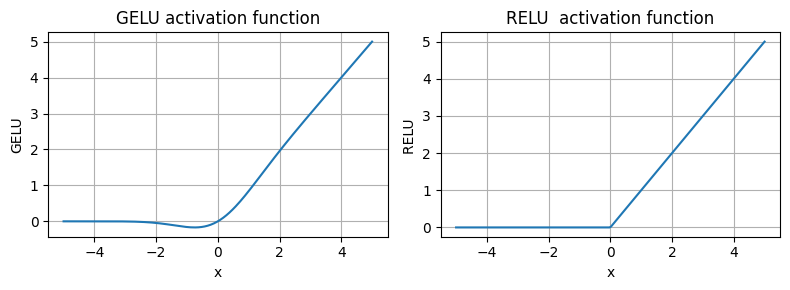

In [13]:
gelu, relu = GELU(), nn.ReLU()

x = torch.linspace(-5, 5, 200)
y_gelu, y_relu = gelu(x), relu(x)
plt.figure(figsize=(8,3))
for i, (y, label) in enumerate(zip([y_gelu, y_relu], ['GELU', 'RELU ']), 1):
    plt.subplot(1,2,i)
    plt.plot(x, y)
    plt.xlabel('x')
    plt.ylabel(label)
    plt.title(f'{label} activation function')
    plt.grid(True)
plt.tight_layout()
plt.show()


In [14]:
help(plt.tight_layout)

Help on function tight_layout in module matplotlib.pyplot:

tight_layout(*, pad=1.08, h_pad=None, w_pad=None, rect=None)
    Adjust the padding between and around subplots.
    
    To exclude an artist on the Axes from the bounding box calculation
    that determines the subplot parameters (i.e. legend, or annotation),
    set ``a.set_in_layout(False)`` for that artist.
    
    Parameters
    ----------
    pad : float, default: 1.08
        Padding between the figure edge and the edges of subplots,
        as a fraction of the font size.
    h_pad, w_pad : float, default: *pad*
        Padding (height/width) between edges of adjacent subplots,
        as a fraction of the font size.
    rect : tuple (left, bottom, right, top), default: (0, 0, 1, 1)
        A rectangle in normalized figure coordinates into which the whole
        subplots area (including labels) will fit.
    
    See Also
    --------
    .Figure.set_tight_layout
    .pyplot.tight_layout



### 增加模型的表达能力
中间层维度扩大 4 倍（如从 768 → 3072）提供了更多的隐藏单元
这相当于在单个 Transformer 层内部增加了一个"瓶颈"结构，让模型能够学习更复杂的非线性变换
### 信息瓶颈与特征提取
输入 (d) → 扩展 (4d) → 非线性激活 → 投影回 (d)
扩展阶段：将信息投影到高维空间，允许模型学习更丰富的特征表示
收缩阶段：通过线性投影筛选和组合最有用的特征，去除噪声

In [15]:
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(cfg["hidden_size"], 4*cfg["hidden_size"]),
            GELU(),
            nn.Linear(4*cfg["hidden_size"], cfg["hidden_size"])
        )
    def forward(self, x):
        return self.fc(x)
    

In [16]:
class ExampleDeepNerualNetwor(nn.Module):
    def __init__(self, shortcut, embeddim_list):
        super().__init__()
        self.shortcut = shortcut
        self.layers = nn.ModuleList(
            [nn.Sequential(nn.Linear(embeddim_list[i], embeddim_list[i+1]), GELU()) for i in range(len(embeddim_list) - 1)]
        )
    
    def forward(self, x):
        for layer in self.layers:
            out = layer(x)
            if self.shortcut and x.shape == out.shape:
                x = x + out
            else:
                x = out
        return x



In [17]:
def print_gradients(x, y, model):
    out = model(x)
    print(f"Output shape: {out.shape}")
    loss = nn.MSELoss()(out, y)
    loss.backward()
    for name, param in model.named_parameters():
        if 'weight' in name:
            print(f"{name} gradient mean: {param.grad.abs().mean().item():.6f}")


In [18]:
model_with_shortcut = ExampleDeepNerualNetwor(shortcut=True, embeddim_list=[3,3,3,3,3,1])
model_without_shortcut = ExampleDeepNerualNetwor(shortcut=False, embeddim_list=[3,3,3,3,3,1])

x = torch.randn(2, 3)
y = torch.randn(2, 1)
print("Gradients for model with shortcut:")
print_gradients(x, y, model_with_shortcut)
print("\nGradients for model without shortcut:")
print_gradients(x, y, model_without_shortcut)

Gradients for model with shortcut:
Output shape: torch.Size([2, 1])
layers.0.0.weight gradient mean: 0.033641
layers.1.0.weight gradient mean: 0.011386
layers.2.0.weight gradient mean: 0.040556
layers.3.0.weight gradient mean: 0.022339
layers.4.0.weight gradient mean: 0.245652

Gradients for model without shortcut:
Output shape: torch.Size([2, 1])
layers.0.0.weight gradient mean: 0.001156
layers.1.0.weight gradient mean: 0.000422
layers.2.0.weight gradient mean: 0.002343
layers.3.0.weight gradient mean: 0.006864
layers.4.0.weight gradient mean: 0.071057


![](./phs/p1.png)

In [ ]:
class MultiHeadAttention(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.head_dim = cfg["hidden_size"] // cfg["num_heads"]
        self.num_heads = cfg["num_heads"]
        self.w_q = nn.Linear(cfg["hidden_size"], cfg["hidden_size"], bias=cfg["qkv_bias"])
        self.w_k = nn.Linear(cfg["hidden_size"], cfg["hidden_size"], bias=cfg["qkv_bias"])
        self.w_v = nn.Linear(cfg["hidden_size"], cfg["hidden_size"], bias=cfg["qkv_bias"])
        self.w_o = nn.Linear(cfg["hidden_size"], cfg["hidden_size"], bias=cfg["qkv_bias"])
        self.dropout = nn.Dropout(cfg["drop_rate"])
        self.register_buffer("mask",
                torch.triu(torch.ones(cfg["context_size"], cfg["context_size"]), diagonal=1).bool()
        )
    
    def forward(self, x):
        b, t, c = x.size()
        q = self.w_q(x).view(b, t, self.num_heads, self.head_dim).transpose(1, 2)  
        k = self.w_k(x).view(b, t, self.num_heads, self.head_dim).transpose(1, 2)  
        v = self.w_v(x).view(b, t, self.num_heads, self.head_dim).transpose(1, 2)  
        attn_scores = (q @ k.transpose(-2, -1)) / torch.sqrt(torch.tensor(self.head_dim, dtype=torch.float32))  
        attn_scores = attn_scores.masked_fill(self.mask[:t, :t], float('-inf')) 
        attn_weights = torch.softmax(attn_scores, dim=-1)  
        attn_weights = self.dropout(attn_weights) 
        attn_output = attn_weights @ v  
        attn_output = attn_output.transpose(1, 2).contiguous().view(b, t, c)  
        return self.w_o(attn_output)  

* Attention：全局交互，建立 token 之间的关系
* Feed Forward：局部变换，增强每个 token 的表达能力

In [20]:
class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.norm1 = LayerNorm(cfg)
        self.norm2 = LayerNorm(cfg)
        self.attn = MultiHeadAttention(cfg)
        self.dropout = nn.Dropout(cfg["drop_rate"])
        self.ffn = FeedForward(cfg)
    
    def forward(self, x):
        short_cut = x
        x = self.norm1(x)
        x = self.attn(x)
        x = self.dropout(x)
        x = x + short_cut

        short_cut = x
        x = self.norm2(x)
        x = self.ffn(x)
        x = self.dropout(x)
        x = x + short_cut
        return x

In [21]:
x1 = torch.randn(2, GPT_CONFIG_124M["context_size"], GPT_CONFIG_124M["hidden_size"])
block = TransformerBlock(GPT_CONFIG_124M)
out = block(x1)
print(out.shape)  # Should be (2, context_size, hidden_size)

torch.Size([2, 1024, 768])


一开始就dropout是为了防止 Embedding 过拟合
* Embedding 层参数量巨大（在这个 124M 模型中，token embedding 就有 3800 多万参数，占总参数约 24%）
* 如果没有 dropout，模型可能会过度依赖某些特定的 embedding 维度
* Dropout 强迫模型学习更鲁棒的表示，不依赖单个维度

In [ ]:
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.embeddings = nn.Embedding(cfg["vocab_size"], cfg["hidden_size"])
        self.pos_emb = nn.Embedding(cfg["context_size"], cfg["hidden_size"])
        self.drop = nn.Dropout(cfg["drop_rate"])
        self.blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["num_layers"])]
        )
        self.final_norm = LayerNorm(cfg)
        self.out_head = nn.Linear(cfg["hidden_size"], cfg["vocab_size"], bias=False)
    
    def forward(self, idx):
        b, t = idx.size()
        token_emb = self.embeddings(idx)  
        pos_emb = self.pos_emb(torch.arange(t, device=idx.device))  # (t, hidden_size)
        x = self.drop(token_emb + pos_emb) 
        x = self.blocks(x)  
        x = self.final_norm(x) 
        return self.out_head(x)  

In [23]:
model = GPTModel(GPT_CONFIG_124M)
batch = torch.randint(0, GPT_CONFIG_124M["vocab_size"], (2, GPT_CONFIG_124M["context_size"]))  # (b, t)
out = model(batch)
print(out.shape)  # Should be (2, context_size, vocab_size)

torch.Size([2, 1024, 50257])


In [24]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters in GPT-124M: {total_params:,}")

Total parameters in GPT-124M: 163,000,320


In [26]:
token_embed_nums = sum(p.numel() for p in model.embeddings.parameters())
print(f"Token embedding parameters: {token_embed_nums:,}")

Token embedding parameters: 38,597,376


In [32]:
f'{163000320 - 38597376:,}'

'124,402,944'

In [31]:
atten_nums = 0
ffn_nums = 0
for p in model.blocks.named_parameters():
    if 'attn' in p[0]:
        atten_nums += p[1].numel()
    elif 'ffn' in p[0]:
        ffn_nums += p[1].numel()
print(f"Attention parameters: {atten_nums:,}")
print(f"Feedforward parameters: {ffn_nums:,}")

Attention parameters: 28,311,552
Feedforward parameters: 56,669,184


In [64]:
def generate_text(model, idx, max_new_tokens, context_size):
    for _ in range(max_new_tokens):
        idx_used = idx[:, -context_size:]
        logits = model(idx_used)[:, -1, :]  # (b, vocab_size)
        # print(f"Logits shape: {logits.shape}")
        next_token = torch.argmax(logits, dim=-1, keepdim=True)  # (b, t, 1)
        # print(f"Next token shape: {next_token.shape}")
        idx = torch.cat([idx, next_token], dim=1)
        # print(f"Updated idx shape: {idx.shape}")
    return idx

In [65]:
start_text = "Hello, I am"
model = GPTModel(GPT_CONFIG_124M)
tokenizer = tiktoken.get_encoding("gpt2")
input_idx = torch.tensor(tokenizer.encode(start_text)).unsqueeze(0)  # (1, t)
print(input_idx.shape)

torch.Size([1, 4])


In [66]:
model.eval()  
generate_text = generate_text(model, input_idx, max_new_tokens=10, context_size=GPT_CONFIG_124M["context_size"])
print(generate_text.shape)

torch.Size([1, 14])


In [67]:
print(tokenizer.decode(generate_text[0].tolist()))

Hello, I amocument taxisRequest Finishedilyn Position Ac countless deliber vessels
